### Step 1: Install Libraries

In [2]:
pip install requests beautifulsoup4 pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

## Step 3: Send Request

In [4]:
url = "https://quotes.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


## Step 4: Parse HTML

In [5]:
soup = BeautifulSoup(response.text, "html.parser")

## Step 5: Show HTML Structure

In [6]:
print(soup.prettify()[:1000])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Quotes to Scrape
  </title>
  <link href="/static/bootstrap.min.css" rel="stylesheet"/>
  <link href="/static/main.css" rel="stylesheet"/>
 </head>
 <body>
  <div class="container">
   <div class="row header-box">
    <div class="col-md-8">
     <h1>
      <a href="/" style="text-decoration: none">
       Quotes to Scrape
      </a>
     </h1>
    </div>
    <div class="col-md-4">
     <p>
      <a href="/login">
       Login
      </a>
     </p>
    </div>
   </div>
   <div class="row">
    <div class="col-md-8">
     <div class="quote" itemscope="" itemtype="http://schema.org/CreativeWork">
      <span class="text" itemprop="text">
       “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
      </span>
      <span>
       by
       <small class="author" itemprop="author">
        Albert Einstein
       </small>
       <a href="/author/Albert

## Step 6: Inspect Specific HTML Element

In [7]:
quote = soup.find("span", class_="text")
print(quote)

<span class="text" itemprop="text">“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”</span>


## Step 7: Extract Quotes

In [8]:
quotes = soup.find_all("span", class_="text")

for q in quotes[:5]:
    print(q.text)

“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
“It is our choices, Harry, that show what we truly are, far more than our abilities.”
“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”


## Step 8: Extract Authors

In [9]:
authors = soup.find_all("small", class_="author")

for a in authors[:5]:
    print(a.text)

Albert Einstein
J.K. Rowling
Albert Einstein
Jane Austen
Marilyn Monroe


## Step 9: Create Dataset

In [10]:
quote_list = []
author_list = []

for quote in quotes:
    quote_list.append(quote.text)

for author in authors:
    author_list.append(author.text)

df = pd.DataFrame({
    "Quote": quote_list,
    "Author": author_list
})

df.head()

,Quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


## Step 10: Save to CSV

In [11]:
df.to_csv("quotes.csv", index=False)

print("File Saved Successfully")

File Saved Successfully


## Step 11: Basic Analysis

### Top Authors

In [12]:
df["Author"].value_counts().head(10)

Author
Albert Einstein      3
J.K. Rowling         1
Jane Austen          1
Marilyn Monroe       1
André Gide           1
Thomas A. Edison     1
Eleanor Roosevelt    1
Steve Martin         1
Name: count, dtype: int64

### Author Chart

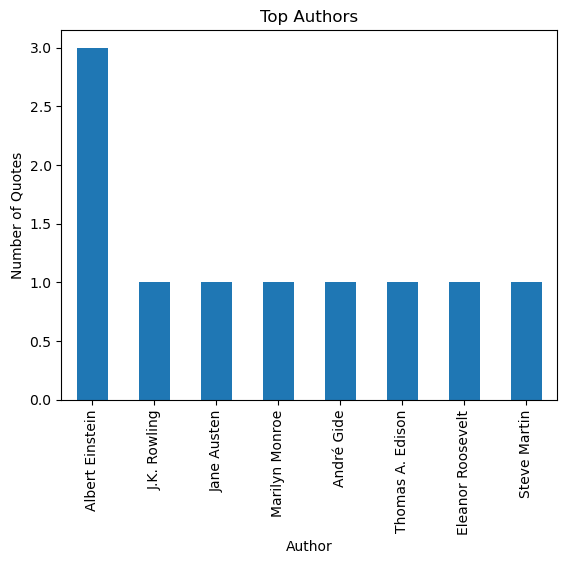

In [13]:
import matplotlib.pyplot as plt

top_authors = df["Author"].value_counts().head(10)

top_authors.plot(kind="bar")

plt.title("Top Authors")
plt.xlabel("Author")
plt.ylabel("Number of Quotes")
plt.show()

### Step 12: Insights

Key Insights

1. Successfully scraped quotes and author names from a public website.
2. Created a structured dataset using BeautifulSoup.
3. Converted unstructured HTML data into CSV format.
4. Identified authors with the highest number of quotes.
5. Demonstrated web scraping, data extraction, and basic analysis skills.